In [1]:
# import packages
using BlockArrays
using LinearAlgebra
using UnPack
using LinearSolve 
using IncompleteLU
using SparseArrays
using Ferrite
using FerriteGmsh 
using OrdinaryDiffEq
using DifferentialEquations
using Plots 
using WriteVTK
using IterativeSolvers
using Interpolations
using LaTeXStrings
using Sundials

In [ ]:
# declare variables
Ca = 59.187
Cd = 9.57
Ea = 21179.6
Ed = 16473
eps = 0.5
rho_emp = 7164
rho_sat = 7259
R = 8.314
Aa = 10.7
Ba = 3704.6
Ad = 10.57
Bd = 3704.6
Ta = 301.15
Td = 305.15
# Pas = [10., 15., 20.]
# Pds = [1.5, 1.75, 2.]
Pref = 10
Peqa = Pref * exp((Aa - Ba / Ta))
Peqd = Pref * exp((Ad - Bd / Td))
# uxs = [0.1, 1., 10.]
D = 1.
L = 0.8
H = 0.04
viscosity = 8.9e-6
K = 1e-9
damping = viscosity / K
ω = 0.1
Ptot = 5e5;

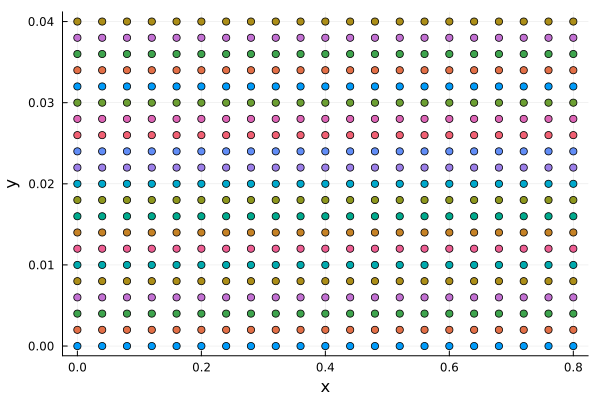

In [3]:
# initialize grid
nels  = (20, 20) # number of elements in each spatial direction
left  = Vec((0., 0.))  # start point for geometry 
right = Vec((L, H,))   # end point for geometry
grid = generate_grid(Quadrilateral,nels,left,right)
#..mesh in x-direction and y-direction - intended for debugging 
xgrid = Vector(range(0, L, step=L/nels[1]))
ygrid = Vector(range(0, H, step=H/nels[2]))
ygrid2 = repeat(ygrid',length(xgrid))
#..lower left grid node - intended for pressure constraint. 
addvertexset!(grid, "corner", (x) -> x[1] ≈ 0.0 && x[2] ≈ 0.0)
if (true) 
    scatter(xgrid,ygrid2,shape=:circle, legend=false, xlabel="x", ylabel="y")
end 

In [4]:
# define postprocess function
function mypostprocess(u, dh)
 
    area = [] 
    velx = [] 
    vely = []
    velm = [] 
    pres = []

    for (cell_num, cell) in enumerate(CellIterator(dh))

        dof_range_u = dof_range(dh,:u)
        dof_range_p = dof_range(dh,:p)
        uloc = u[celldofs(dh,cell_num)[dof_range_u]]
        ploc = u[celldofs(dh,cell_num)[dof_range_p]]
        Ferrite.reinit!(cvu, cell)
        Ferrite.reinit!(cvp, cell)
        
        cellarea = 0. 
        cellvelocity = [0.,0.]
        cellpressure = 0 
    
        for q_point in 1:getnquadpoints(cvu)
            dΩ = getdetJdV(cvu, q_point)
            velocity = function_value(cvu, q_point, uloc)
            cellarea += dΩ 
            cellvelocity += velocity*dΩ
        end

        for q_point in 1:getnquadpoints(cvp)
            dΩ = getdetJdV(cvp, q_point)
            pressure = function_value(cvp, q_point, ploc)
            cellpressure += pressure*dΩ
        end

        append!(area, cellarea)
        append!(velx, cellvelocity[1]/cellarea) 
        append!(vely, cellvelocity[2]/cellarea)
        append!(velm, norm(cellvelocity)/cellarea)
        append!(pres, cellpressure/cellarea)
    
    end  

    velx2d = reshape(velx, nels)
    vely2d = reshape(vely, nels)
    velm2d = reshape(velm, nels)
    pres2d = reshape(pres, nels)
    
    return area, velx2d, vely2d, velm2d, pres2d  
end; 

In [5]:
# define assembly functions
function assemble_mass_matrix!(cellvalues_v::CellValues, cellvalues_p::CellValues, M::SparseMatrixCSC, dh::DofHandler)
    # Allocate a buffer for the local matrix and some helpers, together with the assembler.
    n_basefuncs_v = getnbasefunctions(cellvalues_v)
    n_basefuncs_p = getnbasefunctions(cellvalues_p)
    n_basefuncs = n_basefuncs_v + n_basefuncs_p
    v▄, p▄ = 1, 2
    # Mₑ = BlockedArray(zeros(n_basefuncs, n_basefuncs), [n_basefuncs_v, n_basefuncs_p], [n_basefuncs_v, n_basefuncs_p])
    Mₑ = BlockArray(zeros(n_basefuncs, n_basefuncs), [n_basefuncs_v, n_basefuncs_p], [n_basefuncs_v, n_basefuncs_p])
    
    # It follows the assembly loop as explained in the basic tutorials.
    mass_assembler = start_assemble(M)
    for cell in CellIterator(dh)
        fill!(Mₑ, 0)
        Ferrite.reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dΩ = getdetJdV(cellvalues_v, q_point)
            # Remember that we assemble a vector mass term, hence the dot product.
            # There is only one time derivative on the left hand side, so only one mass block is non-zero.
            for i in 1:n_basefuncs_v
                φᵢ = shape_value(cellvalues_v, q_point, i)
                for j in 1:n_basefuncs_v
                    φⱼ = shape_value(cellvalues_v, q_point, j)
                    Mₑ[BlockIndex((v▄, v▄), (i, j))] += φᵢ ⋅ φⱼ * dΩ
                end
            end
        end
        assemble!(mass_assembler, celldofs(cell), Mₑ)
    end

    return M
end

function assemble_stokes_matrix!(K, dh, cvu, cvp, viscosity, damping)
    assembler = start_assemble(K)
    ke = zeros(ndofs_per_cell(dh), ndofs_per_cell(dh))
    range_u = dof_range(dh, :u)
    ndofs_u = length(range_u)
    range_p = dof_range(dh, :p)
    ndofs_p = length(range_p)
    ϕᵤ = Vector{Vec{2,Float64}}(undef, ndofs_u)
    ∇ϕᵤ = Vector{Tensor{2,2,Float64,4}}(undef, ndofs_u) # 2-by-2 tensor 
    divϕᵤ = Vector{Float64}(undef, ndofs_u)
    ϕₚ = Vector{Float64}(undef, ndofs_p)
    for cell in CellIterator(dh)
        Ferrite.reinit!(cvu, cell)
        Ferrite.reinit!(cvp, cell)
        coords = getcoordinates(cell)
        ke .= 0
        for qp in 1:getnquadpoints(cvu)
            dΩ = getdetJdV(cvu, qp)
            for i in 1:ndofs_u
                ϕᵤ[i] = shape_value(cvu, qp, i)
                ∇ϕᵤ[i] = shape_gradient(cvu, qp, i)
                divϕᵤ[i] = shape_divergence(cvu, qp, i)
            end
            for i in 1:ndofs_p
                ϕₚ[i] = shape_value(cvp, qp, i)
            end
            # u-u
            for (i, I) in pairs(range_u), (j, J) in pairs(range_u)
                ke[I, J] += viscosity*( ∇ϕᵤ[i] ⊡ ∇ϕᵤ[j] ) * dΩ + damping*( ϕᵤ[i]⋅ϕᵤ[j] ) * dΩ 
            end
            # u-p
            for (i, I) in pairs(range_u), (j, J) in pairs(range_p)
                ke[I, J] += ( -divϕᵤ[i] * ϕₚ[j] ) * dΩ
            end
            # p-u
            for (i, I) in pairs(range_p), (j, J) in pairs(range_u)
                ke[I, J] += ( -divϕᵤ[j] * ϕₚ[i] ) * dΩ
            end
        end
        assemble!(assembler, celldofs(cell), ke)
    end
    return K 
end;

## Steady-State Model

┌ Warning: adding constraint to nodeset is not recommended for sub/super-parametric approximations.
└ @ Ferrite C:\Users\jasmi\.julia\packages\Ferrite\nQ2S0\src\Dofs\ConstraintHandler.jl:424


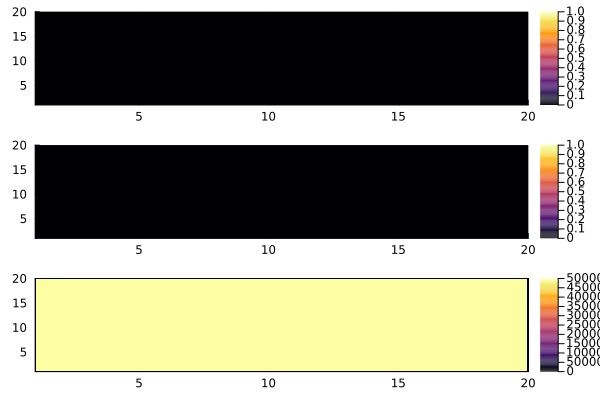

In [6]:
# interpolations
dim = 2
degree = 2

ipu = Lagrange{RefQuadrilateral,degree+1}() ^ dim
ipp = Lagrange{RefQuadrilateral,degree}()

# DoFs
dh = DofHandler(grid)
add!(dh, :u, ipu)
add!(dh, :p, ipp)
close!(dh)

# FE values
qr = QuadratureRule{RefQuadrilateral}(2*degree+1)
ipg = Lagrange{RefQuadrilateral,1}()

cvu = CellValues(qr, ipu, ipg)
cvp = CellValues(qr, ipp, ipg)

qr_facet = FacetQuadratureRule{RefQuadrilateral}(2)
fvp = FacetValues(qr_facet, ipp, ipg) # pressure mean constraint
fvu = FacetValues(qr_facet, ipu, ipg) # inlet total-pressure traction

ch = ConstraintHandler(dh)

inlet = getfacetset(grid, "left")

zero_u_boundary = union(
    getfacetset(grid, "right"),
    getfacetset(grid, "top"),
    getfacetset(grid, "bottom"),
)

# u = 0 on all boundaries except the inlet
dbc_u0 = Dirichlet(:u, zero_u_boundary, (x, t) -> [0.0, 0.0])
add!(ch, dbc_u0)

# set on bottem-left corner p = Ptot for uniqueness
xref = Vec((0.8, 0.0))
tol = 1e-10

addnodeset!(grid, "p_ref", x -> norm(x - xref) < tol)
p_ref = getnodeset(grid, "p_ref")

dbc_p_ref = Dirichlet(:p, p_ref, (x, t) -> Ptot)
add!(ch, dbc_p_ref)

close!(ch)

# building 1/2 u^2 + p = Ptot boundary condition for inlet
function assemble_total_pressure_inlet!(f, dh, fvu, inlet, u_old, Ptot)

    u_range = dof_range(dh, :u)

    for facet in FacetIterator(dh, inlet)
        Ferrite.reinit!(fvu, facet)

        cell_dofs = celldofs(facet)
        cell_u_dofs = cell_dofs[u_range]

        ue = u_old[cell_u_dofs]

        for q in 1:Ferrite.getnquadpoints(fvu)
            dΓ = Ferrite.getdetJdV(fvu, q)
            n = Ferrite.getnormal(fvu, q)

            uh = Ferrite.function_value(fvu, q, ue)

            # note that this is nonlinear and Neumann, therefore we weakly impose the boundary condition to the RHS
            p_bc = max(Ptot - 0.5 * dot(uh, uh), 0.0)
            traction = -p_bc * n

            for i in 1:Ferrite.getnbasefunctions(fvu)
                δu = Ferrite.shape_value(fvu, q, i)
                f[cell_u_dofs[i]] += dot(δu, traction) * dΓ
            end
        end
    end

    return f
end

coupling = [true true; true true]

# this does not matter as bc do not depend on t
t = 0

# we do u = 0 as initial guess, since we want p=Ptot for steady state at inlet
u_old = zeros(ndofs(dh))
u = similar(u_old)

# need nonlinear iteration because p_bc depends on u
for iter in 1:25
    K = allocate_matrix(dh, ch; coupling=coupling)
    f = zeros(ndofs(dh))

    K = assemble_stokes_matrix!(K, dh, cvu, cvp, viscosity, damping)
    f = assemble_total_pressure_inlet!(f, dh, fvu, inlet, u_old, Ptot)

    update!(ch, t)
    apply!(K, f, ch)

    u .= K \ f

    err = norm(u - u_old) / max(norm(u), 1e-12)
    err < 1e-8 && break

    # extra relaxation for faster convergence and stability
    u_old .= (1 - ω) .* u_old .+ ω .* u
end

VTKGridFile("stokes_total_pressure_inlet", dh) do vtk
    write_solution(vtk, dh, u)
    Ferrite.write_constraints(vtk, ch)
end

area, velx2d, vely2d, velm2d, pres2d = mypostprocess(u, dh)

p1 = contour(round.(velx2d';digits=4), fill=true, levels=100)
p2 = contour(round.(vely2d';digits=4), fill=true, levels=100)
p4 = contour(round.(pres2d';digits=4), fill=true, levels=100)

plot(p1, p2, p4, layout=(3,1))

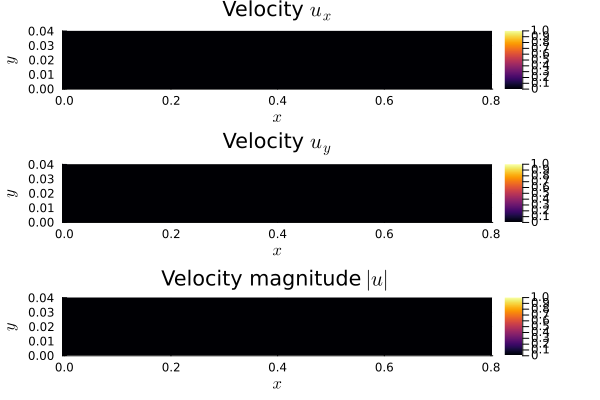

In [7]:
function smooth_field(field; factor=6)
    field = Float64.(field)
    nx, ny = size(field)

    itp = Interpolations.interpolate(
        field,
        Interpolations.BSpline(
            Interpolations.Cubic(Interpolations.Line(Interpolations.OnGrid()))
        )
    )

    xs = range(1, nx; length=nx*factor)
    ys = range(1, ny; length=ny*factor)

    smooth = [itp(x, y) for x in xs, y in ys]
    return xs, ys, smooth
end

xs, ys, velx_s = smooth_field(velx2d)
_,  _, vely_s = smooth_field(vely2d)
_,  _, pres_s = smooth_field(pres2d)
_, _, velm_s = smooth_field(velm2d)

x_phys = range(0, L; length=length(xs))
y_phys = range(0, H; length=length(ys))

p1 = heatmap(x_phys, y_phys, round.(velx_s';digits=4),
    title=L"Velocity $u_x$",
    xlabel=L"$x$",
    ylabel=L"$y$",
    right_margin=10Plots.mm)
p2 = heatmap(x_phys, y_phys, round.(vely_s';digits=4),
    title=L"Velocity $u_y$",
    xlabel=L"$x$",
    ylabel=L"$y$",
    right_margin=10Plots.mm)
p3 = heatmap(x_phys, y_phys, round.(velm_s';digits=4),
    title=L"Velocity magnitude $|u|$",
    xlabel=L"$x$",
    ylabel=L"$y$",
    right_margin=10Plots.mm)
p4 = heatmap(x_phys, y_phys, round.(pres_s';digits=4),
    title=L"Pressure $p_g$",
    xlabel=L"$x$",
    ylabel=L"$y$",
    right_margin=10Plots.mm,
    up_margin=15Plots.mm)

# display(p1)
# display(p2)
# display(p3)
plot(p1,p2,p3,layout=(3,1))

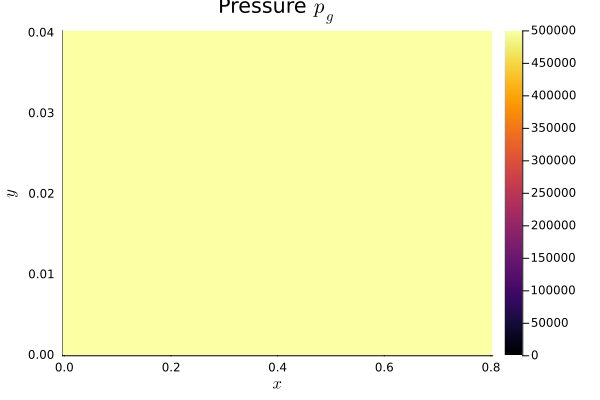

In [8]:
display(p4)

## Transient Model

In [17]:
# set time
T  = 0.001
dt = 1e-5
tspan = (0.0, T)

# u = 0 on all boundaries except the inlet
ch = ConstraintHandler(dh)
dbc_u0 = Dirichlet(:u, zero_u_boundary, (x, t) -> [0.0, 0.0])
add!(ch, dbc_u0)

# set on bottom-left corner p = Ptot for uniqueness
dbc_p_ref = Dirichlet(:p, p_ref, (x, t) -> Ptot)
add!(ch, dbc_p_ref)

close!(ch)
update!(ch, 0.0)

# allocate and assemble mass matrix
M = allocate_matrix(dh, ch)
M = assemble_mass_matrix!(cvu, cvp, M, dh)

# allocate and assemble stiffness matrix
K = allocate_matrix(dh, ch)
K = assemble_stokes_matrix!(K, dh, cvu, cvp, viscosity, damping)

# allocate forcing
f = zeros(ndofs(dh))
f_bc = zeros(ndofs(dh))

# initial guesses
un = zeros(ndofs(dh))
dun = zeros(ndofs(dh))

apply!(un, ch)

pvd = paraview_collection("stokes_transient")

VTKGridFile("stokes_transient_0", dh) do vtk
    write_solution(vtk, dh, round.(un; digits=6))
    pvd[0.0] = vtk
end

function residual!(res, du, u, p, t)
    fill!(f_bc, 0.0)
    assemble_total_pressure_inlet!(f_bc, dh, fvu, inlet, u, Ptot)
    res .= M * du .+ K * u .- f .- f_bc
end

diff_vars = vec(sum(abs.(M), dims=2) .> 0)
prob = DAEProblem(residual!,dun,un,tspan,differential_vars=diff_vars)
sol = solve(prob,IDA(),initializealg = BrownFullBasicInit(),dtmax = dt,abstol = 1e-5,reltol = 1e-5)

rm.(filter(f -> startswith(f, "stokes_transient"), readdir()))

for (i,t) in enumerate(sol.t)

    uh = sol.u[i]

    VTKGridFile("stokes_transient-$i", dh) do vtk
        write_solution(vtk, dh, round.(uh; digits=6))
        pvd[t] = vtk
    end
end

vtk_save(pvd);

┌ Warning: adding constraint to nodeset is not recommended for sub/super-parametric approximations.
└ @ Ferrite C:\Users\jasmi\.julia\packages\Ferrite\nQ2S0\src\Dofs\ConstraintHandler.jl:424
